# Step 5 • Cleaning Climate Data (Brazil & Vietnam)
Cleaning weather data from Brazil and Vietnam. We chose as the two biggest coffee producers in order to see if climate patterns help explain coffee price movements.

Brazil data is from INMET (Brazil's national weather institute) and Vietnam data is from a Kaggle scrape. Both need to get aggregated down to monthly since that's the timescale where climate actually affects harvests.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Brazil (INMET)

Source: https://www.kaggle.com/datasets/gregoryoliveira/brazil-weather-information-by-inmet

Aggregated summary (`weather_sum_all.csv`) with daily values

In [2]:
brazil = pd.read_csv('data/00-raw/brazil-weather.csv')
brazil.shape

(3289529, 11)

In [3]:
brazil.columns.tolist()

['ESTACAO',
 'DATA (YYYY-MM-DD)',
 'rain_max',
 'rad_max',
 'temp_avg',
 'temp_max',
 'temp_min',
 'hum_max',
 'hum_min',
 'wind_max',
 'wind_avg']

In [4]:
brazil.head()

,ESTACAO,DATA (YYYY-MM-DD),rain_max,rad_max,temp_avg,temp_max,temp_min,hum_max,hum_min,wind_max,wind_avg
0,A001,2000-05-07,0.0,2915.0,25.125000,28.3,20.7,69.0,36.0,6.3,1.766667
1,A001,2000-05-08,0.0,3126.0,22.104167,28.2,16.5,86.0,33.0,7.1,2.066667
2,A001,2000-05-09,0.0,2901.0,22.041667,28.7,16.6,79.0,37.0,7.0,1.150000
3,A001,2000-05-10,0.0,2972.0,22.462500,28.9,17.7,82.0,35.0,6.3,2.008333
4,A001,2000-05-11,0.0,2958.0,21.329167,27.3,16.6,80.0,35.0,7.3,2.670833


Lots of columns we don't need; some even in Portuguese haha. 

Focusing on temperature and precipitation as those are the two climate variables we chose that are most directly tied to coffee crop yields. Station ID is kept to see how many stations are in the dataset

In [5]:
brazil = brazil[['ESTACAO', 'DATA (YYYY-MM-DD)', 'temp_avg', 'rain_max']]
brazil.columns = ['station', 'date', 'temp_mean', 'precip_mm']
brazil.head()

,station,date,temp_mean,precip_mm
0,A001,2000-05-07,25.125000,0.0
1,A001,2000-05-08,22.104167,0.0
2,A001,2000-05-09,22.041667,0.0
3,A001,2000-05-10,22.462500,0.0
4,A001,2000-05-11,21.329167,0.0


In [6]:
print(f"{brazil['station'].nunique()} stations")

647 stations


There's a total of 647 stations in total. 

Minas Gerais is area in Brazil that produces most of their coffee. We don't have specific station location beyond the codes (take average of 647 stations). Another thing to keep in mind as a limitation for our analysis since particular areas might not be representative of the whole country's climate and how that affects coffee price.

In [7]:
brazil = brazil.drop_duplicates(subset=['station', 'date']).reset_index(drop=True)
print(f"After dropping duplicates: {brazil.shape}")

After dropping duplicates: (3148414, 4)


In [8]:
brazil['date'] = pd.to_datetime(brazil['date'], errors='coerce')
brazil['temp_mean'] = pd.to_numeric(brazil['temp_mean'], errors='coerce')
brazil['precip_mm'] = pd.to_numeric(brazil['precip_mm'], errors='coerce')

brazil.sort_values('date', inplace=True)
brazil.reset_index(drop=True, inplace=True)
brazil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3148414 entries, 0 to 3148413
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   station    object        
 1   date       datetime64[ns]
 2   temp_mean  float64       
 3   precip_mm  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 96.1+ MB


In [9]:
brazil.isnull().sum()

station           0
date              0
temp_mean     12167
precip_mm    190156
dtype: int64

In [10]:
brazil[['temp_mean', 'precip_mm']].describe()

,temp_mean,precip_mm
count,3.136247e+06,2.958258e+06
mean,2.352096e+01,1.845338e+00
std,4.428758e+00,5.103646e+00
min,-5.037692e+01,0.000000e+00
25%,2.123750e+01,0.000000e+00
50%,2.437083e+01,0.000000e+00
75%,2.654583e+01,8.000000e-01
max,4.490000e+01,1.382000e+02


Min temp is -50.4°C — significant error or outlier. 

Dropping temps below -10°C since Brazil's average weather doesn't drop below that low.

In [11]:
bad = (brazil['temp_mean'] < -10).sum()
brazil = brazil[brazil['temp_mean'] >= -10].reset_index(drop=True)

print(f"dropped {bad} rows with temp below -10°C")

dropped 365 rows with temp below -10°C


In [12]:
# aggregate daily -> monthly
brazil['year_month'] = brazil['date'].dt.to_period('M')

brazil_monthly = brazil.groupby('year_month').agg(
    temp_mean=('temp_mean', 'mean'),
    precip_total=('precip_mm', 'sum')
).reset_index()

brazil_monthly['year_month'] = brazil_monthly['year_month'].dt.to_timestamp()
print(brazil_monthly.shape)
brazil_monthly.head(12)

(309, 3)


,year_month,temp_mean,precip_total
0,2000-05-01,22.432417,40.4
1,2000-06-01,22.539826,40.8
2,2000-07-01,21.511641,120.6
3,2000-08-01,23.138155,68.4
4,2000-09-01,22.891764,235.8
5,2000-10-01,23.733549,263.4
6,2000-11-01,23.844869,426.6
7,2000-12-01,25.165124,220.2
8,2001-01-01,25.423930,323.8
9,2001-02-01,25.763652,233.2


In [13]:
print(f"{brazil_monthly['year_month'].min()} to {brazil_monthly['year_month'].max()}")
brazil_monthly.isnull().sum()

2000-05-01 00:00:00 to 2026-01-01 00:00:00


year_month      0
temp_mean       0
precip_total    0
dtype: int64

# Vietnam

https://www.kaggle.com/datasets/vanviethieuanh/vietnam-weather-data

Cleaner dataset compared to Brazil with 2009–2021 years

In [14]:
vietnam = pd.read_csv('data/00-raw/vietnam-weather.csv')
vietnam.shape

(181960, 10)

In [15]:
vietnam.head()

,province,max,min,wind,wind_d,rain,humidi,cloud,pressure,date
0,Bac Lieu,27,22,17,NNE,6.9,90,71,1010,2009-01-01
1,Bac Lieu,31,25,20,ENE,0.0,64,24,1010,2010-01-01
2,Bac Lieu,29,24,14,E,0.0,75,45,1008,2011-01-01
3,Bac Lieu,30,24,30,E,0.0,79,52,1012,2012-01-01
4,Bac Lieu,31,25,20,ENE,0.0,70,24,1010,2013-01-01


In [16]:
vietnam.isnull().sum()

province    0
max         0
min         0
wind        0
wind_d      0
rain        0
humidi      0
cloud       0
pressure    0
date        0
dtype: int64

No missing values at all, keep `max`, `min` (daily high/low temp), and `rain` (daily precip)

In [17]:
vietnam = vietnam[['date', 'max', 'min', 'rain']]
vietnam.columns = ['date', 'temp_max', 'temp_min', 'precip_mm']

vietnam['temp_mean'] = (vietnam['temp_max'] + vietnam['temp_min']) / 2
vietnam.drop(columns=['temp_max', 'temp_min'], inplace=True)
vietnam.head()

,date,precip_mm,temp_mean
0,2009-01-01,6.9,24.5
1,2010-01-01,0.0,28.0
2,2011-01-01,0.0,26.5
3,2012-01-01,0.0,27.0
4,2013-01-01,0.0,28.0


In [18]:
vietnam['date'] = pd.to_datetime(vietnam['date'], errors='coerce')
vietnam['precip_mm'] = pd.to_numeric(vietnam['precip_mm'], errors='coerce')
vietnam['temp_mean'] = pd.to_numeric(vietnam['temp_mean'], errors='coerce')
vietnam.sort_values('date', inplace=True)
vietnam.reset_index(drop=True, inplace=True)

In [19]:
vietnam.duplicated(subset=['date']).sum()

177411

In [20]:
vietnam[['temp_mean', 'precip_mm']].describe()

,temp_mean,precip_mm
count,181960.000000,181960.000000
mean,26.557576,6.567130
std,4.018722,13.602055
min,3.500000,0.000000
25%,24.500000,0.100000
50%,27.500000,1.800000
75%,29.000000,7.500000
max,37.000000,596.400000


In [21]:
# daily -> monthly, same as Brazil
vietnam['year_month'] = vietnam['date'].dt.to_period('M')

vietnam_monthly = vietnam.groupby('year_month').agg(
    temp_mean=('temp_mean', 'mean'),
    precip_total=('precip_mm', 'sum')
).reset_index()

vietnam_monthly['year_month'] = vietnam_monthly['year_month'].dt.to_timestamp()
print(vietnam_monthly.shape)
vietnam_monthly.head(12)

(150, 3)


,year_month,temp_mean,precip_total
0,2009-01-01,21.152823,2217.2
1,2009-02-01,25.691071,1790.6
2,2009-03-01,25.988306,4768.1
3,2009-04-01,27.182500,11140.4
4,2009-05-01,26.795161,14339.5
5,2009-06-01,28.342083,8896.1
6,2009-07-01,27.569355,12022.8
7,2009-08-01,28.004032,11781.7
8,2009-09-01,27.034167,16356.8
9,2009-10-01,26.040323,11319.5


In [22]:
print(f"{vietnam_monthly['year_month'].min()} to {vietnam_monthly['year_month'].max()}")
vietnam_monthly.isnull().sum()

2009-01-01 00:00:00 to 2021-06-01 00:00:00


year_month      0
temp_mean       0
precip_total    0
dtype: int64

## Combining Brazil & Vietnam
Merging Brazil and Vietnam side-by-side on `year_month` so each row has climate data from both countries.

Outer joining these two countries since Brazil goesto 2000 but Vietnam starts in 2009.

In [23]:
climate_monthly = brazil_monthly[['year_month', 'temp_mean', 'precip_total']].rename(
    columns={'temp_mean': 'brazil_temp_mean', 'precip_total': 'brazil_precip_total'}
)

climate_monthly = climate_monthly.merge(
    vietnam_monthly[['year_month', 'temp_mean', 'precip_total']].rename(
        columns={'temp_mean': 'vietnam_temp_mean', 'precip_total': 'vietnam_precip_total'}
    ),
    on='year_month',
    how='outer'
)

climate_monthly.sort_values('year_month', inplace=True)
climate_monthly.reset_index(drop=True, inplace=True)
climate_monthly

,year_month,brazil_temp_mean,brazil_precip_total,vietnam_temp_mean,vietnam_precip_total
0,2000-05-01,22.432417,40.4,NaN,NaN
1,2000-06-01,22.539826,40.8,NaN,NaN
2,2000-07-01,21.511641,120.6,NaN,NaN
3,2000-08-01,23.138155,68.4,NaN,NaN
4,2000-09-01,22.891764,235.8,NaN,NaN
...,...,...,...,...,...
304,2025-09-01,23.563001,8071.9,NaN,NaN
305,2025-10-01,23.659499,13530.2,NaN,NaN
306,2025-11-01,24.074285,20748.8,NaN,NaN
307,2025-12-01,25.065679,30566.5,NaN,NaN


In [24]:
climate_monthly.isnull().sum()

year_month                0
brazil_temp_mean          0
brazil_precip_total       0
vietnam_temp_mean       159
vietnam_precip_total    159
dtype: int64

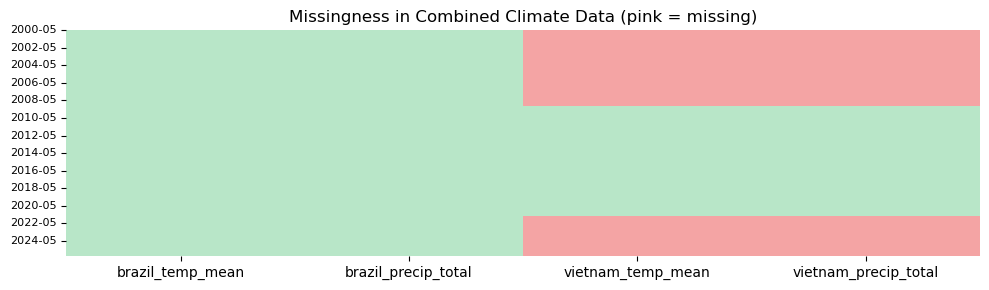

In [25]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(10, 3))
cmap = ListedColormap(['#B8E6C8', '#F4A4A4'])  # pastel green = present, pastel red = missing

heatmap_data = climate_monthly.set_index('year_month').isnull()
sns.heatmap(heatmap_data, cbar=False, cmap=cmap, ax=ax)

tick_positions = range(0, len(heatmap_data), 24)
tick_labels = [heatmap_data.index[i].strftime('%Y-%m') for i in tick_positions]
ax.set_yticks(list(tick_positions))
ax.set_yticklabels(tick_labels, fontsize=8)

ax.set_title('Missingness in Combined Climate Data (pink = missing)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

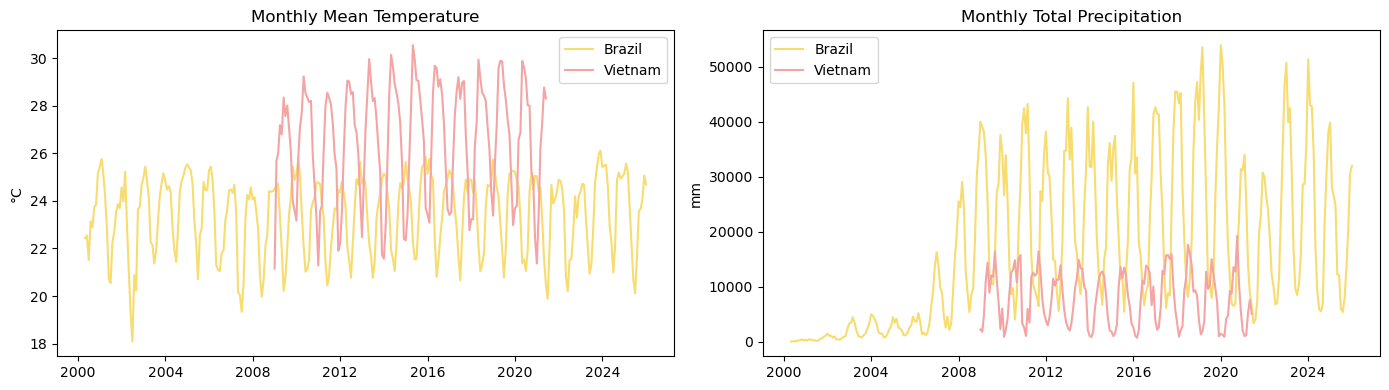

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

brazil_c = '#F7DC6F'
vietnam_c = '#F4A4A4'

ax1.plot(climate_monthly['year_month'], climate_monthly['brazil_temp_mean'], 
         label='Brazil', color=brazil_c, linewidth=1.5)
ax1.plot(climate_monthly['year_month'], climate_monthly['vietnam_temp_mean'], 
         label='Vietnam', color=vietnam_c, linewidth=1.5)
ax1.set_title('Monthly Mean Temperature')
ax1.set_ylabel('°C')
ax1.legend()

ax2.plot(climate_monthly['year_month'], climate_monthly['brazil_precip_total'], 
         label='Brazil', color=brazil_c, linewidth=1.5)
ax2.plot(climate_monthly['year_month'], climate_monthly['vietnam_precip_total'], 
         label='Vietnam', color=vietnam_c, linewidth=1.5)
ax2.set_title('Monthly Total Precipitation')
ax2.set_ylabel('mm')
ax2.legend()

plt.tight_layout()
plt.show()

In [27]:
climate_monthly.to_csv('data/02-processed/climate_clean.csv', index=False)
print('done, yay! :) saved to data/02-processed/climate_clean.csv')

done, yay! :) saved to data/02-processed/climate_clean.csv
